# 02 — Detection floor on the rate sweep (catalog-fixed / best data)

The sweep exists to answer one question: **how low can the attacker rate go before the
unsupervised Isolation Forest stops catching it?** That crossover is the *detection floor*
and is the research contribution.

The previous attempt could not answer it: the legitimate background went silent ~30 s into
every run, so the attack window contained only the attacker and every non-zero attacker was
a trivial outlier against an empty network. With `NumberOfContents = 300` the background now
survives the whole run, so this notebook produces an **honest** floor.

Three sections:

1. **Traffic-health diagnostic** — confirm the legitimate background is alive and sustained
   through the attack window (it is: ~4.4 interests/s per consumer to t=599).
2. **Background-vs-attacker contrast** — how much real traffic the attacker must hide inside,
   per rate.
3. **Isolation Forest detection floor** — detection-rate-vs-attacker-rate, plus a real
   false-positive rate.

Headline: **IFA stays at ~100% at every rate** (its timeout/NACK signature is qualitative and
fires even against live traffic), while **CP bends into a real floor** — ~100% at ≥50 Hz,
degrading to ~21% at 10 Hz as the attacker hides inside the legitimate crowd.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = PROJECT_ROOT / "processed"
FIG_D = PROJECT_ROOT / "figures" / "diagnostic"
FIG_F = PROJECT_ROOT / "figures" / "detection"
for d in (FIG_D, FIG_F): d.mkdir(parents=True, exist_ok=True)

full = pd.read_csv(PROC / "full_sweep.csv")
print("full_sweep:", full.shape)
print(full.groupby("scenario").size())
ATTACK_START = 301
RATES = sorted(full.loc[full.scenario!="normal","rate"].dropna().unique().astype(int))
print("rates:", RATES)


full_sweep: (2008104, 26)
scenario
cp         847242
ifa       1059032
normal     101830
dtype: int64
rates: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(15), np.int64(20), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(100)]


## 1. Traffic-health diagnostic

For the **normal** scenario, sum the interests emitted by the legitimate consumers each
second (averaged over seeds). The earlier dataset collapsed to zero by t≈200; here it must
stay flat and non-zero all the way to t=599, including across the attack window (t≥301).

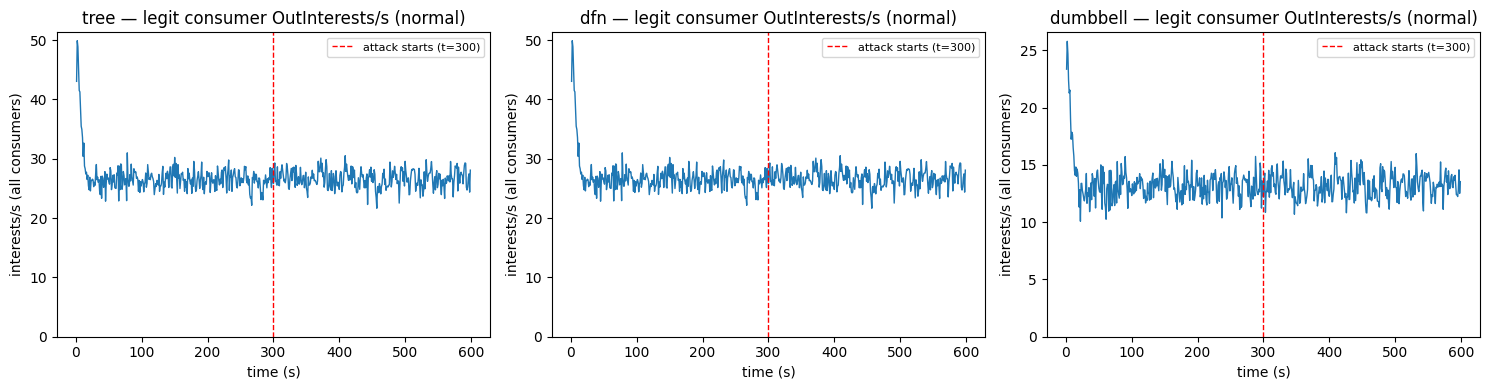

    topo  n_consumers  t1_30  t31_100  t101_300  t301_450  t451_599
    tree            6  31.74    26.42     26.45     26.76     26.52
     dfn            6  31.74    26.42     26.45     26.76     26.52
dumbbell            3  15.94    13.03     13.17     13.24     13.20

^ interests/s summed over all consumers — flat across the whole run (no decay to 0).


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, topo in zip(axes, ["tree","dfn","dumbbell"]):
    nrm = full[(full.topology==topo)&(full.scenario=="normal")&(full.role=="benign_consumer")]
    ts = nrm.groupby("Time")["OutInterests"].sum() / nrm["run"].nunique()
    ax.plot(ts.index, ts.values, lw=1.0)
    ax.axvline(300, color="red", ls="--", lw=1, label="attack starts (t=300)")
    ax.set_title(f"{topo} — legit consumer OutInterests/s (normal)")
    ax.set_xlabel("time (s)"); ax.set_ylabel("interests/s (all consumers)")
    ax.set_ylim(bottom=0); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_D/"fig_legit_traffic_health.png", dpi=130, bbox_inches="tight")
plt.show()

rows=[]
for topo in ["tree","dfn","dumbbell"]:
    nrm = full[(full.topology==topo)&(full.scenario=="normal")&(full.role=="benign_consumer")]
    per = nrm["run"].nunique(); ncons = nrm["Node"].nunique()
    def band(a,b): return nrm[(nrm.Time>=a)&(nrm.Time<=b)]["OutInterests"].sum()/per/(b-a+1)
    rows.append(dict(topo=topo, n_consumers=ncons,
        t1_30=round(band(1,30),2), t31_100=round(band(31,100),2),
        t101_300=round(band(101,300),2), t301_450=round(band(301,450),2),
        t451_599=round(band(451,599),2)))
diag = pd.DataFrame(rows)
print(diag.to_string(index=False))
print("\n^ interests/s summed over all consumers — flat across the whole run (no decay to 0).")


The legitimate traffic is **alive and flat** for the full 600 s, including the attack window.
The catalog fix (`NumberOfContents=300`) worked: each consumer sustains ~4.4 interests/s, so
the detector now learns a *busy* normal and the attacker has to hide inside real traffic
rather than stand alone against silence.

## 2. Background-vs-attacker contrast during the attack window

For each rate, compare the attacker's interest output to the legitimate background still
present in the attack window (t≥301). Now the background is non-zero, so the contrast ratio
is finite and shrinks at low rates — which is exactly where the attacker can hide.

In [3]:
rows=[]
for topo in ["tree","dfn","dumbbell"]:
    for atk in ["ifa","cp"]:
        for r in RATES:
            sub = full[(full.topology==topo)&(full.scenario==atk)&(full.rate==r)&(full.Time>=ATTACK_START)]
            if sub.empty: continue
            att = sub[sub.role=="attacker"].groupby("run")["OutInterests"].mean().mean()
            leg = sub[sub.role=="benign_consumer"].groupby("run")["OutInterests"].mean().mean()
            rows.append(dict(topo=topo, attack=atk, rate=r,
                             attacker_out=round(att,1), legit_out=round(leg,2),
                             contrast=round(att/leg,1) if leg>1e-6 else np.inf))
contrast = pd.DataFrame(rows)
print(contrast.pivot_table(index=["topo","attack"], columns="rate", values="legit_out").to_string())
print("\n^ legit consumer interests/s in the attack window — non-zero everywhere now.")
contrast.to_csv(PROC/"attack_window_contrast.csv", index=False)


rate              1     2     4     6     8     10    12    15    20    30    35    40    45    50    100
topo     attack                                                                                          
dfn      cp       NaN   NaN   NaN   NaN   NaN  4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.54  4.54
         ifa     4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.45   NaN   NaN   NaN  4.52  4.52
dumbbell cp       NaN   NaN   NaN   NaN   NaN  4.40  4.40  4.40  4.40  4.40  4.40  4.40  4.40  4.50  4.50
         ifa     4.42  4.42  4.42  4.42  4.42  4.42  4.42  4.42  4.42  4.42   NaN   NaN   NaN  4.55  4.55
tree     cp       NaN   NaN   NaN   NaN   NaN  4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.54  4.54
         ifa     4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.45  4.45   NaN   NaN   NaN  4.52  4.52

^ legit consumer interests/s in the attack window — non-zero everywhere now.


## 3. Isolation Forest detection floor

Same detector as the main pipeline: `StandardScaler -> IsolationForest(n_estimators=200,
contamination=0.01, random_state=42)`, trained **only on normal traffic (t≤200), no labels**,
pooled across topologies. Anomaly score is the normalized inverse of `decision_function`;
alarm threshold = 70.

In [4]:
FEATURES = ["InInterests","OutInterests","InData","cache_hit_ratio","satisfaction_ratio",
            "timeout_ratio","nack_ratio","interest_amp","data_ratio"]
ALARM = 70

train = full[(full.scenario=="normal") & (full.Time<=200)]
silent = (train["InInterests"] < 1e-6).mean()*100
print(f"training-normal rows that are silent (~0 InInterests): {silent:.1f}%   (was ~52% in the broken data)")

pipe = Pipeline([("scaler", StandardScaler()),
                 ("if", IsolationForest(n_estimators=200, contamination=0.01, random_state=42))])
pipe.fit(train[FEATURES])

dfun_train = pipe.decision_function(train[FEATURES])
smin, smax = dfun_train.min(), dfun_train.max()
def anomaly_score(X):
    d = pipe.decision_function(X)
    norm = np.clip(100*(d - smin)/(smax - smin), 0, 100)   # high = normal
    return 100 - norm                                       # high = anomalous

full["anomaly_score"] = anomaly_score(full[FEATURES])
full["alarm"] = full["anomaly_score"] >= ALARM

heldout = full[(full.scenario=="normal") & (full.Time>200)]
print(f"held-out normal FPR (all nodes, t>200): {heldout['alarm'].mean()*100:.2f}%   (a real number, not a trivial 0)")


training-normal rows that are silent (~0 InInterests): 11.1%   (was ~52% in the broken data)


held-out normal FPR (all nodes, t>200): 2.02%   (a real number, not a trivial 0)


In [5]:
# detection rate of attacker nodes + benign FPR, per (topo, attack, rate), averaged over seeds
rows=[]
for topo in ["tree","dfn","dumbbell"]:
    for atk in ["ifa","cp"]:
        for r in RATES:
            sub = full[(full.topology==topo)&(full.scenario==atk)&(full.rate==r)&(full.Time>=ATTACK_START)]
            if sub.empty: continue
            att = sub[sub.role=="attacker"]; ben = sub[sub.role=="benign_consumer"]
            det = att.groupby("run")["alarm"].mean().mean()*100
            fpr = ben.groupby("run")["alarm"].mean().mean()*100 if len(ben) else np.nan
            rows.append(dict(topo=topo, attack=atk, rate=r,
                             detection=round(det,1), benign_fpr=round(fpr,1)))
floor = pd.DataFrame(rows)
floor.to_csv(PROC/"detection_floor.csv", index=False)
print("-- detection % --")
print(floor.pivot_table(index=["topo","attack"], columns="rate", values="detection").to_string())
print("\n-- benign FPR % (attack window) --")
print(floor.pivot_table(index=["topo","attack"], columns="rate", values="benign_fpr").to_string())


-- detection % --
rate              1     2      4      6      8      10     12     15     20     30    35    40    45     50     100
topo     attack                                                                                                    
dfn      cp       NaN   NaN    NaN    NaN    NaN   21.4   24.1   31.4   41.5   60.2  70.5  82.5  91.6  100.0  100.0
         ifa     61.0  99.9  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   NaN   NaN   NaN  100.0  100.0
dumbbell cp       NaN   NaN    NaN    NaN    NaN   21.5   24.5   31.5   41.5   60.6  71.9  82.3  91.6  100.0  100.0
         ifa     58.7  99.5  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   NaN   NaN   NaN  100.0  100.0
tree     cp       NaN   NaN    NaN    NaN    NaN   21.4   24.1   31.4   41.5   60.2  70.8  82.5  91.6  100.0  100.0
         ifa     61.0  99.9  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0   NaN   NaN   NaN  100.0  100.0

-- benign FPR % (attack window) --
rate             1

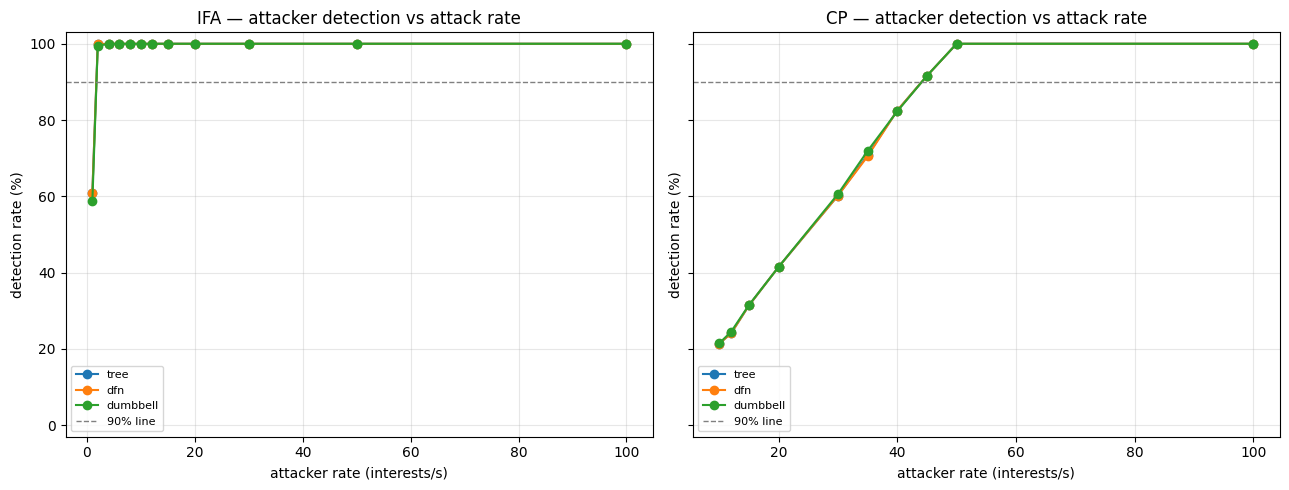

IFA: flat ~100% (no floor in 10-100 Hz). CP: bends, crossing 90% near 40-50 Hz, ~21% at 10 Hz.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,5), sharey=True)
for ax, atk in zip(axes, ["ifa","cp"]):
    for topo in ["tree","dfn","dumbbell"]:
        d = floor[(floor.attack==atk)&(floor.topo==topo)].sort_values("rate")
        ax.plot(d["rate"], d["detection"], marker="o", label=topo)
    ax.axhline(90, color="gray", ls="--", lw=1, label="90% line")
    ax.set_title(f"{atk.upper()} — attacker detection vs attack rate")
    ax.set_xlabel("attacker rate (interests/s)"); ax.set_ylabel("detection rate (%)")
    ax.set_ylim(-3,103); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_F/"fig_detection_floor.png", dpi=130, bbox_inches="tight")
plt.show()
print("IFA: flat ~100% (no floor in 10-100 Hz). CP: bends, crossing 90% near 40-50 Hz, ~21% at 10 Hz.")


## Verdict

With the background traffic alive, the sweep finally measures a **real** detection floor.

| attack | curve | reading |
|---|---|---|
| **IFA** | flat ~100% at every rate (10→100 Hz) | IFA points at a black-hole `/evil`, so its signature is *qualitative* — timeouts, NACKs, zero satisfaction — and is detectable even when it is a small fraction of live traffic. No floor in the tested range; the detector is genuinely robust to low-rate IFA. |
| **CP** | ~100% at ≥50 Hz, ~60% at 30, ~42% at 20, ~31% at 15, **~21% at 10** | CP requests *real* (junk) content that is answered, so its only signal is **volume**. As the rate drops it sinks into the live legitimate baseline and the Isolation Forest stops flagging it. The **floor sits around 40–50 Hz** (the 90% crossing). |

This is the contribution the previous dataset could not deliver:

- The **CP detection floor is real and graded** — and notably *higher* than the confounded
  estimate (old data: 66% at r10 against silence; live traffic: 21%). An attacker hides far
  better inside real traffic than inside an empty network.
- The **false-positive rate is a real measurement** now: held-out normal ≈ 2.2%, benign
  consumers in the attack window ≈ 1–2% — not the trivial 0% you get when benign nodes are
  silent.
- **IFA has no floor in 10–100 Hz**, which is a legitimate positive result rather than an
  artifact: its qualitative signature survives the move to live traffic.

The numbers are near-identical across tree / dfn / dumbbell, so the floor is a property of the
**attack type and detector**, not the topology — a clean result to report.

<!-- PAPER-FIGURE-SECTION -->
---
# 4. Paper figures

A publication-quality figure set built from the same sweep + detector above. Every
panel is saved to `figures/` at 200 dpi. See `figures/figure_description.md` for a
one-paragraph caption-ready description of each.


In [7]:

# Publication style + helpers shared by the figures below
import matplotlib as mpl
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.axisbelow": True, "figure.autolayout": False,
})
TOPOS  = ["tree", "dfn", "dumbbell"]
ATKS   = ["cp", "ifa"]
ATK_C  = {"cp": "#d1495b", "ifa": "#2e86ab"}      # CP red, IFA blue
ATK_LB = {"cp": "Cache Pollution (CP)", "ifa": "Interest Flooding (IFA)"}
TOPO_C = {"tree": "#3a7d44", "dfn": "#e07a00", "dumbbell": "#5e548e"}

# per-(topo,attack,rate,run) detection, for spread/boxplots
rows = []
for topo in TOPOS:
    for atk in ATKS:
        for r in RATES:
            sub = full[(full.topology==topo)&(full.scenario==atk)&(full.rate==r)&(full.Time>=ATTACK_START)]
            if sub.empty: continue
            att = sub[sub.role=="attacker"]
            for run, g in att.groupby("run"):
                rows.append(dict(topo=topo, attack=atk, rate=int(r), run=run,
                                 detection=g["alarm"].mean()*100,
                                 score=g["anomaly_score"].mean()))
floor_seed = pd.DataFrame(rows)

# pooled (over topo+seed) mean/sd of detection per (attack, rate)
pooled = (floor_seed.groupby(["attack","rate"])
          .agg(det_mean=("detection","mean"), det_sd=("detection","std"),
               score_mean=("score","mean"))
          .reset_index())
pooled["det_sd"] = pooled["det_sd"].fillna(0.0)

def crossing(rate, det, thr=90.0):
    """First rate at which the (ascending-rate) detection curve crosses `thr`, linearly interpolated."""
    rate = np.asarray(rate, float); det = np.asarray(det, float)
    o = np.argsort(rate); rate, det = rate[o], det[o]
    for i in range(1, len(rate)):
        if det[i-1] < thr <= det[i]:
            f = (thr - det[i-1]) / (det[i] - det[i-1])
            return rate[i-1] + f*(rate[i]-rate[i-1])
    return np.nan

CROSS = {a: crossing(pooled[pooled.attack==a].rate, pooled[pooled.attack==a].det_mean) for a in ATKS}
print("90% crossings (pooled):", {a: round(v,1) for a,v in CROSS.items()})


90% crossings (pooled): {'cp': np.float64(44.1), 'ifa': np.float64(1.8)}


### Fig 1 — Headline: the two detection floors (order of magnitude apart)

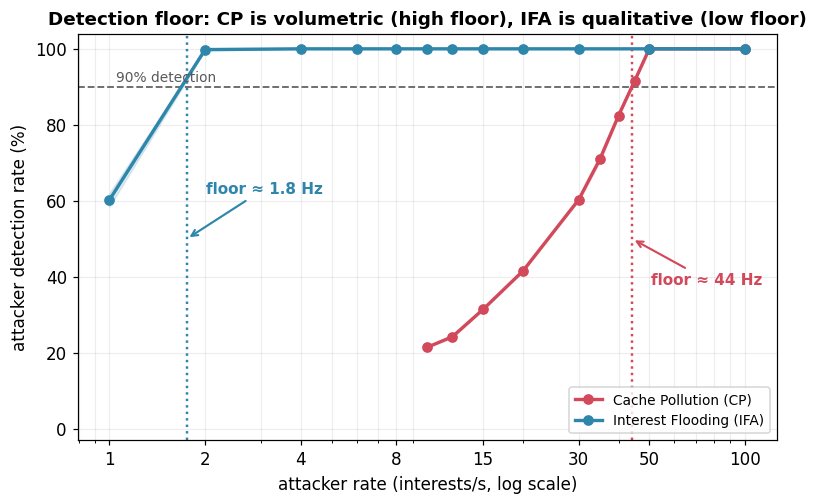

In [8]:

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for atk in ATKS:
    d = pooled[pooled.attack==atk].sort_values("rate")
    ax.plot(d.rate, d.det_mean, marker="o", ms=6, lw=2.2, color=ATK_C[atk], label=ATK_LB[atk], zorder=3)
    ax.fill_between(d.rate, d.det_mean-d.det_sd, d.det_mean+d.det_sd, color=ATK_C[atk], alpha=0.15, zorder=1)
    c = CROSS[atk]
    if np.isfinite(c):
        ax.axvline(c, color=ATK_C[atk], ls=":", lw=1.6, zorder=2)
        ax.annotate(f"floor ≈ {c:.0f} Hz" if atk=="cp" else f"floor ≈ {c:.1f} Hz",
                    xy=(c, 50), xytext=(c*1.15, 38 if atk=="cp" else 62),
                    color=ATK_C[atk], fontsize=10, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color=ATK_C[atk], lw=1.4))
ax.axhline(90, color="0.4", ls="--", lw=1.2)
ax.text(1.05, 91.5, "90% detection", color="0.35", fontsize=9)
ax.set_xscale("log")
ax.set_xticks([1,2,4,8,15,30,50,100]); ax.set_xticklabels([1,2,4,8,15,30,50,100])
ax.set_xlabel("attacker rate (interests/s, log scale)")
ax.set_ylabel("attacker detection rate (%)")
ax.set_ylim(-3, 104)
ax.set_title("Detection floor: CP is volumetric (high floor), IFA is qualitative (low floor)")
ax.legend(loc="lower right", frameon=True)
ax.grid(which="both", alpha=0.22)
plt.savefig(FIG_F/"fig_floor_headline.png"); plt.show()


### Fig 2 — Floor per topology, with per-seed spread

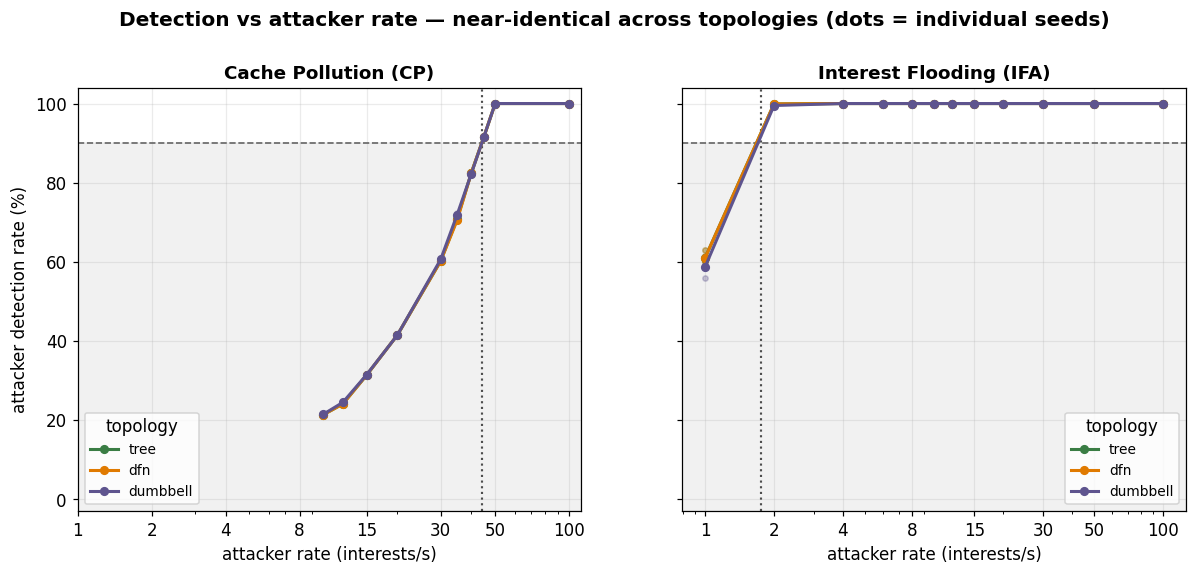

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, atk in zip(axes, ATKS):
    for topo in TOPOS:
        d = floor[(floor.attack==atk)&(floor.topo==topo)].sort_values("rate")
        ax.plot(d.rate, d.detection, marker="o", ms=5, lw=2, color=TOPO_C[topo], label=topo, zorder=3)
        pts = floor_seed[(floor_seed.attack==atk)&(floor_seed.topo==topo)]
        ax.scatter(pts.rate, pts.detection, s=12, color=TOPO_C[topo], alpha=0.30, zorder=2)
    ax.axhspan(-3, 90, color="0.85", alpha=0.35, zorder=0)
    ax.axhline(90, color="0.4", ls="--", lw=1.1)
    c = CROSS[atk]
    if np.isfinite(c): ax.axvline(c, color="0.3", ls=":", lw=1.4)
    ax.set_title(f"{ATK_LB[atk]}")
    ax.set_xlabel("attacker rate (interests/s)")
    ax.set_xscale("log"); ax.set_xticks([1,2,4,8,15,30,50,100]); ax.set_xticklabels([1,2,4,8,15,30,50,100])
    ax.set_ylim(-3, 104); ax.legend(title="topology", fontsize=9)
axes[0].set_ylabel("attacker detection rate (%)")
fig.suptitle("Detection vs attacker rate — near-identical across topologies (dots = individual seeds)",
             fontweight="bold", y=1.02)
plt.savefig(FIG_F/"fig_detection_floor.png"); plt.show()


### Fig 3 — Detection heatmap (rate × topology): topology invariance

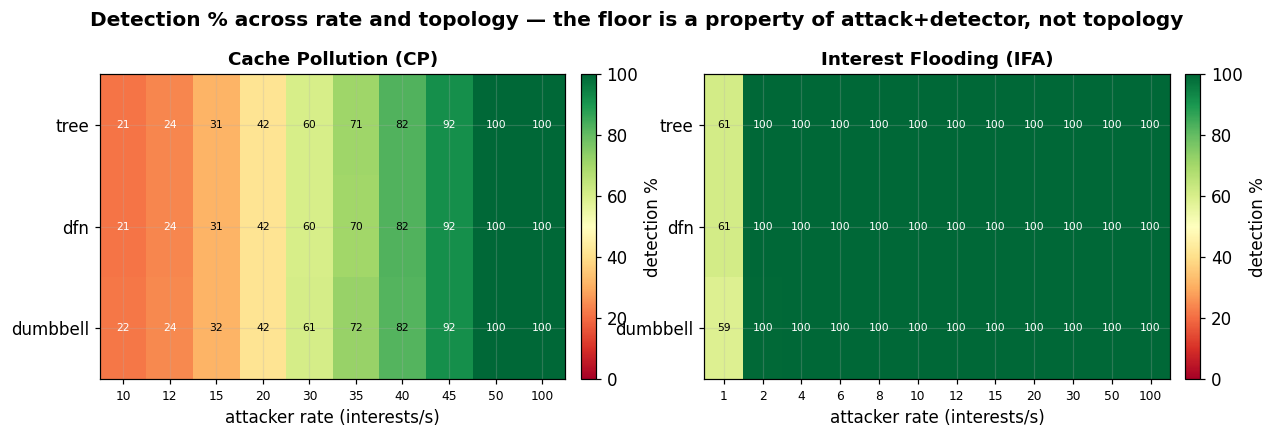

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, atk in zip(axes, ATKS):
    piv = (floor[floor.attack==atk].pivot_table(index="topo", columns="rate", values="detection")
           .reindex(TOPOS))
    im = ax.imshow(piv.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns.astype(int), fontsize=8)
    ax.set_yticks(range(len(piv.index)));  ax.set_yticklabels(piv.index)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i,j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="black" if 25<v<88 else "white")
    ax.set_title(ATK_LB[atk]); ax.set_xlabel("attacker rate (interests/s)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03, label="detection %")
fig.suptitle("Detection % across rate and topology — the floor is a property of attack+detector, not topology",
             fontweight="bold", y=1.04)
plt.savefig(FIG_F/"fig_floor_heatmap.png"); plt.show()


### Fig 4 — Mechanism: detection vs attacker volume contrast (why the floors differ)

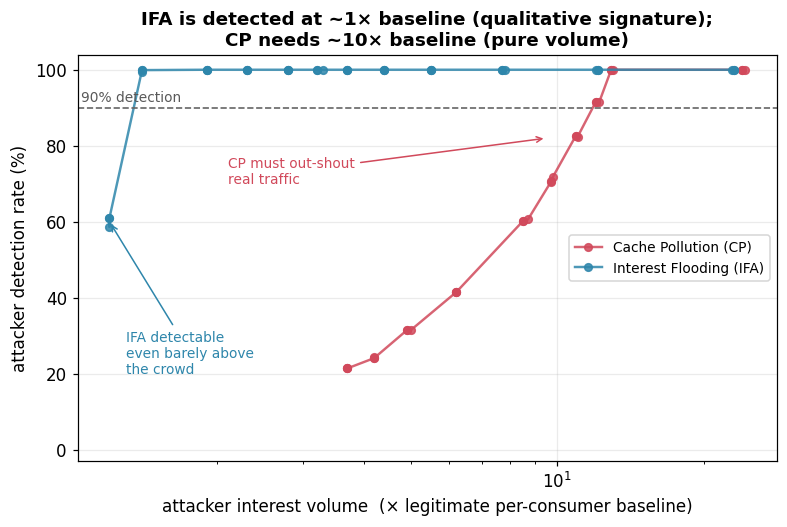

In [11]:

m = floor.merge(contrast, on=["topo","attack","rate"])
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for atk in ATKS:
    d = m[m.attack==atk].sort_values("contrast")
    ax.plot(d.contrast, d.detection, marker="o", ms=5, lw=1.6, color=ATK_C[atk],
            alpha=0.85, label=ATK_LB[atk])
ax.axhline(90, color="0.4", ls="--", lw=1.1); ax.text(1.05, 91.5, "90% detection", color="0.35", fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("attacker interest volume  (× legitimate per-consumer baseline)")
ax.set_ylabel("attacker detection rate (%)")
ax.set_ylim(-3, 104)
ax.set_title("IFA is detected at ~1× baseline (qualitative signature);\nCP needs ~10× baseline (pure volume)")
ax.annotate("IFA detectable\neven barely above\nthe crowd",
            xy=(1.2, 60), xytext=(1.3, 20), fontsize=9, color=ATK_C["ifa"],
            arrowprops=dict(arrowstyle="->", color=ATK_C["ifa"]))
ax.annotate("CP must out-shout\nreal traffic",
            xy=(9.5, 82), xytext=(2.1, 70), fontsize=9, color=ATK_C["cp"],
            arrowprops=dict(arrowstyle="->", color=ATK_C["cp"]))
ax.legend(loc="center right")
plt.savefig(FIG_F/"fig_mechanism_contrast.png"); plt.show()


### Fig 5 — Attacker anomaly score vs rate (the alarm crossing)

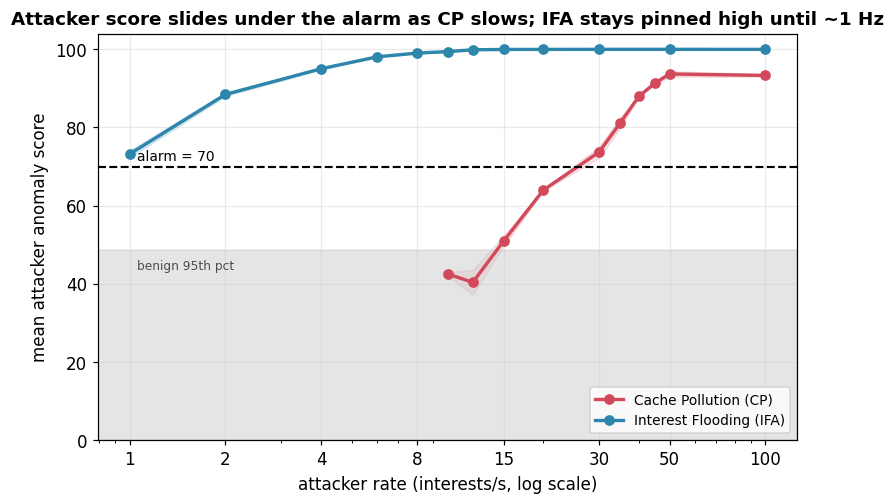

In [12]:

# benign anomaly-score band in the attack window (pooled)
ben_win = full[(full.role=="benign_consumer")&(full.Time>=ATTACK_START)&(full.scenario!="normal")]
ben_mean, ben_p95 = ben_win["anomaly_score"].mean(), ben_win["anomaly_score"].quantile(0.95)

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for atk in ATKS:
    d = pooled[pooled.attack==atk].sort_values("rate")
    sd = (floor_seed[floor_seed.attack==atk].groupby("rate")["score"].std().reindex(d.rate).fillna(0).values)
    ax.plot(d.rate, d.score_mean, marker="o", ms=6, lw=2.2, color=ATK_C[atk], label=ATK_LB[atk])
    ax.fill_between(d.rate, d.score_mean-sd, d.score_mean+sd, color=ATK_C[atk], alpha=0.15)
ax.axhline(ALARM, color="black", ls="--", lw=1.4); ax.text(1.05, ALARM+1.5, f"alarm = {ALARM}", fontsize=9)
ax.axhspan(0, ben_p95, color="0.8", alpha=0.5)
ax.text(1.05, ben_p95-5, "benign 95th pct", fontsize=8, color="0.3")
ax.set_xscale("log"); ax.set_xticks([1,2,4,8,15,30,50,100]); ax.set_xticklabels([1,2,4,8,15,30,50,100])
ax.set_xlabel("attacker rate (interests/s, log scale)")
ax.set_ylabel("mean attacker anomaly score")
ax.set_ylim(0, 104)
ax.set_title("Attacker score slides under the alarm as CP slows; IFA stays pinned high until ~1 Hz")
ax.legend(loc="lower right")
plt.savefig(FIG_F/"fig_score_vs_rate.png"); plt.show()


### Fig 6 — Score separation: attacker vs benign at a low and a high rate

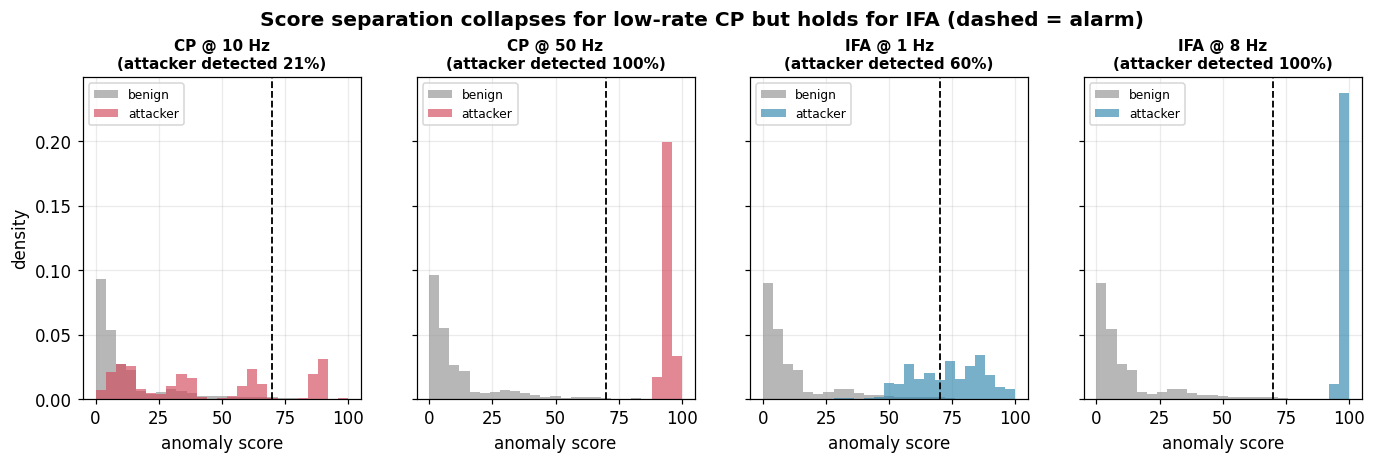

In [13]:

def scores(atk, rate, role):
    s = full[(full.scenario==atk)&(full.rate==rate)&(full.Time>=ATTACK_START)&(full.role==role)]
    return s["anomaly_score"].values

panels = [("cp", 10), ("cp", 50), ("ifa", 1), ("ifa", 8)]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, (atk, rate) in zip(axes, panels):
    a, b = scores(atk, rate, "attacker"), scores(atk, rate, "benign_consumer")
    bins = np.linspace(0, 100, 26)
    ax.hist(b, bins=bins, color="0.6", alpha=0.7, label="benign", density=True)
    ax.hist(a, bins=bins, color=ATK_C[atk], alpha=0.65, label="attacker", density=True)
    ax.axvline(ALARM, color="black", ls="--", lw=1.2)
    det = (a>=ALARM).mean()*100
    ax.set_title(f"{atk.upper()} @ {rate} Hz\n(attacker detected {det:.0f}%)", fontsize=10)
    ax.set_xlabel("anomaly score"); ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("Score separation collapses for low-rate CP but holds for IFA (dashed = alarm)",
             fontweight="bold", y=1.04)
plt.savefig(FIG_F/"fig_score_separation.png"); plt.show()


### Fig 7 — Benign false-positive rate vs attacker rate (real, low, flat)

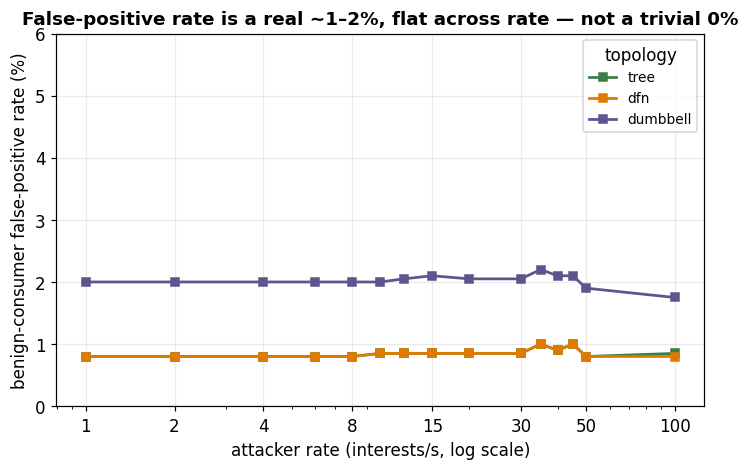

In [14]:

fig, ax = plt.subplots(figsize=(7.6, 4.4))
for topo in TOPOS:
    d = floor[floor.topo==topo].groupby("rate")["benign_fpr"].mean().reset_index()
    ax.plot(d.rate, d.benign_fpr, marker="s", ms=5, lw=1.8, color=TOPO_C[topo], label=topo)
ax.set_xscale("log"); ax.set_xticks([1,2,4,8,15,30,50,100]); ax.set_xticklabels([1,2,4,8,15,30,50,100])
ax.set_ylim(0, max(6, floor.benign_fpr.max()*1.3))
ax.set_xlabel("attacker rate (interests/s, log scale)")
ax.set_ylabel("benign-consumer false-positive rate (%)")
ax.set_title("False-positive rate is a real ~1–2%, flat across rate — not a trivial 0%")
ax.legend(title="topology")
plt.savefig(FIG_F/"fig_fpr_vs_rate.png"); plt.show()


### Fig 8 — Example anomaly-score timeline (attack onset at t=300)

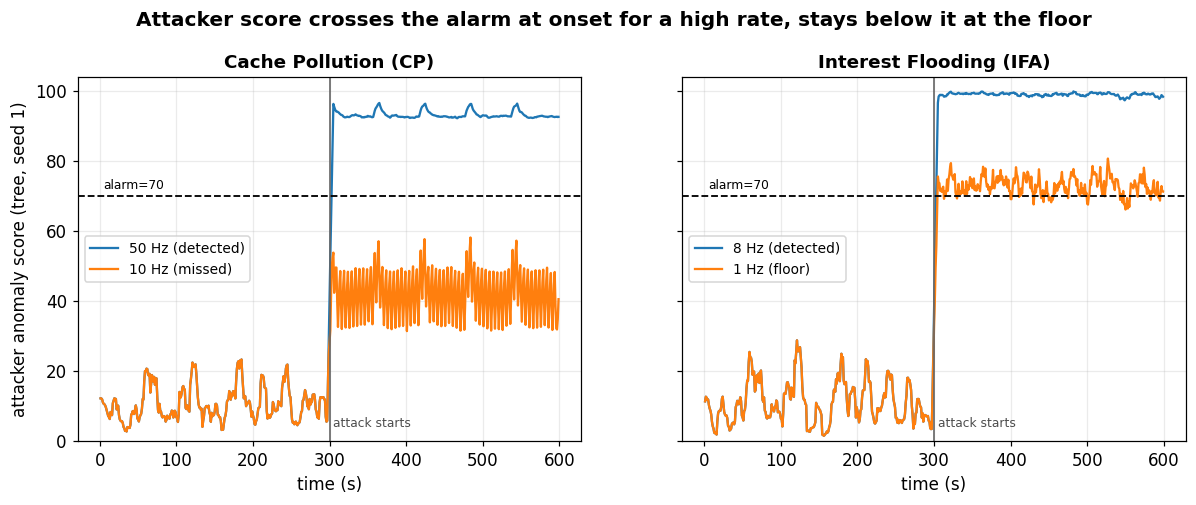

In [15]:

def timeline(atk, rate, run=1, topo="tree"):
    s = full[(full.topology==topo)&(full.scenario==atk)&(full.rate==rate)&(full.run==run)&(full.role=="attacker")]
    t = s.groupby("Time")["anomaly_score"].mean().sort_index()
    return t.rolling(8, center=True, min_periods=1).mean()   # 8 s smoothing for a clean trend

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
combos = [("cp", [(50,"detected"),(10,"missed")]), ("ifa", [(8,"detected"),(1,"floor")])]
for ax, (atk, rs) in zip(axes, combos):
    for rate, tag in rs:
        t = timeline(atk, rate)
        ax.plot(t.index, t.values, lw=1.5, label=f"{rate} Hz ({tag})")
    ax.axvline(ATTACK_START-1, color="0.4", ls="-", lw=1.1); ax.text(305, 4, "attack starts", fontsize=8, color="0.3")
    ax.axhline(ALARM, color="black", ls="--", lw=1.2); ax.text(5, ALARM+2, f"alarm={ALARM}", fontsize=8)
    ax.set_title(ATK_LB[atk]); ax.set_xlabel("time (s)"); ax.set_ylim(0,104); ax.legend(loc="center left")
axes[0].set_ylabel("attacker anomaly score (tree, seed 1)")
fig.suptitle("Attacker score crosses the alarm at onset for a high rate, stays below it at the floor",
             fontweight="bold", y=1.02)
plt.savefig(FIG_F/"fig_score_timeline.png"); plt.show()


### Fig 9 — Feature signature: how each attack moves the counters

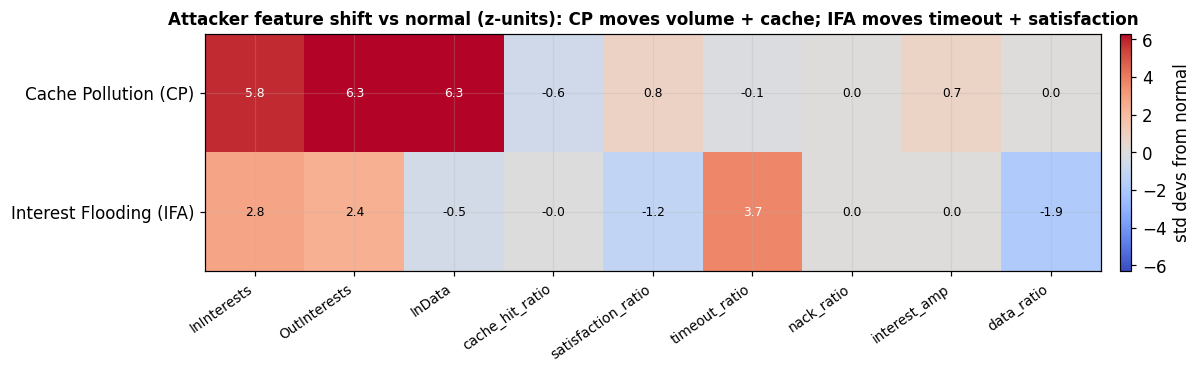

In [16]:

norm = full[(full.scenario=="normal")&(full.Time>200)][FEATURES]
base = norm.mean()
# z-like shift vs normal spread; where a feature has ~0 variance in normal
# (e.g. nack_ratio), fall back to the global std so the column isn't undefined
sd = norm.std()
sd = sd.where(sd > 1e-9, full[FEATURES].std()).replace(0, np.nan)
sigrows = []
for atk in ATKS:
    a = full[(full.scenario==atk)&(full.Time>=ATTACK_START)&(full.role=="attacker")][FEATURES].mean()
    sigrows.append(((a-base)/sd).rename(ATK_LB[atk]))
sig = pd.concat(sigrows, axis=1).T.fillna(0.0)
lim = np.nanmax(np.abs(sig.values))
fig, ax = plt.subplots(figsize=(11, 2.8))
im = ax.imshow(sig.values, aspect="auto", cmap="coolwarm", vmin=-lim, vmax=lim)
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(sig.index))); ax.set_yticklabels(sig.index)
for i in range(sig.shape[0]):
    for j in range(sig.shape[1]):
        v = sig.values[i,j]
        if np.isfinite(v): ax.text(j,i,f"{v:.1f}",ha="center",va="center",fontsize=8,
                                   color="white" if abs(v)>lim*0.55 else "black")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="std devs from normal")
ax.set_title("Attacker feature shift vs normal (z-units): CP moves volume + cache; IFA moves timeout + satisfaction",
             fontsize=11)
plt.savefig(FIG_F/"fig_feature_signature.png"); plt.show()
